# Water Quality Classification Project

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from keras.layers import Dense, Input
from keras.losses import BinaryCrossentropy
from keras.models import Sequential
from keras.optimizers import Adam
from keras.utils import clear_session
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Exploratory Data Analysis

In [3]:
water_data = pd.read_csv('SAFER_RA_cleaned.csv')

# List of columns to include
include_cols = ['TINWSYS_IS_NUMBER', 'CURRENT_FAILING', 'SERVICE_CONNECTIONS', 'POPULATION', 
                'OWNER_TYPE', 'FEDERAL_CLASSIFICATION_TYPE', 'MHI', 'CALENVIRO_SCREEN_SCORE', 
                'REGIONAL_BOARD', 'FUNDING_RECEIVED_SINCE_2017', 
                'TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017'
                ]

water_data_include = water_data[include_cols]

# Check for missing values
water_data_include.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   TINWSYS_IS_NUMBER                        3204 non-null   int64  
 1   CURRENT_FAILING                          3204 non-null   object 
 2   SERVICE_CONNECTIONS                      3204 non-null   int64  
 3   POPULATION                               3204 non-null   int64  
 4   OWNER_TYPE                               3204 non-null   object 
 5   FEDERAL_CLASSIFICATION_TYPE              3204 non-null   object 
 6   MHI                                      3189 non-null   float64
 7   CALENVIRO_SCREEN_SCORE                   3168 non-null   float64
 8   REGIONAL_BOARD                           3161 non-null   object 
 9   FUNDING_RECEIVED_SINCE_2017              3204 non-null   float64
 10  TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017  3204 no

In [4]:
# Drop missing values
water_data_clean = water_data_include.dropna()

<Axes: >

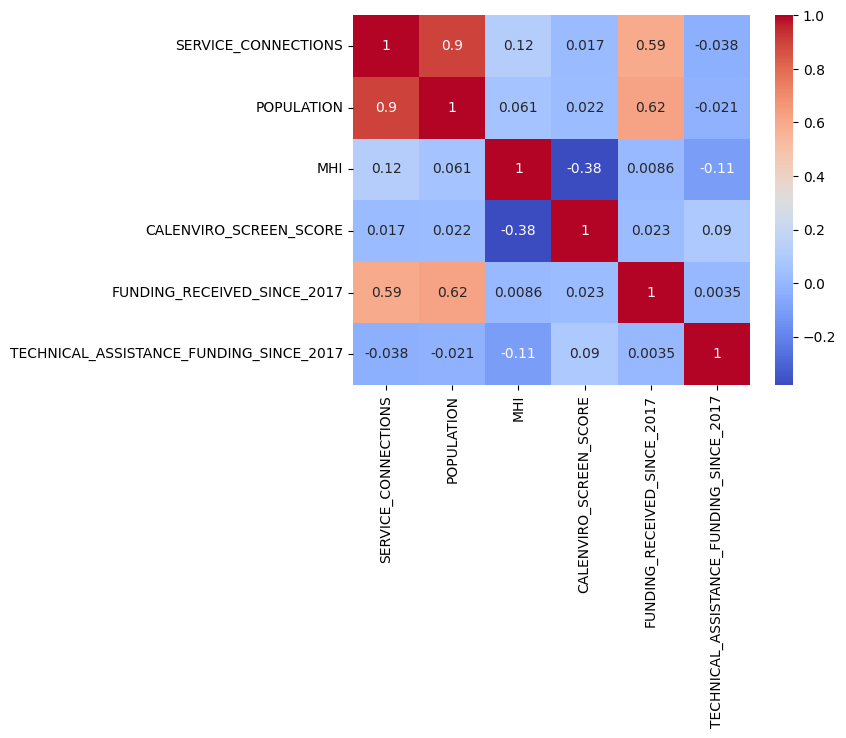

In [5]:
# Identify multicolinearity between continuous variables
water_cont = water_data_clean[['SERVICE_CONNECTIONS', 'POPULATION', 'MHI', 
                           'CALENVIRO_SCREEN_SCORE', 'FUNDING_RECEIVED_SINCE_2017', 
                           'TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017']]

# Heat map
sns.heatmap(water_cont.corr(), annot=True, cmap='coolwarm')



Since SERVICE_CONNECTIONS and POPULATION are strongly correlated, we dropped SERVICE_CONNECTIONS from our predictors.

## Preprocessing

<Axes: ylabel='TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017'>

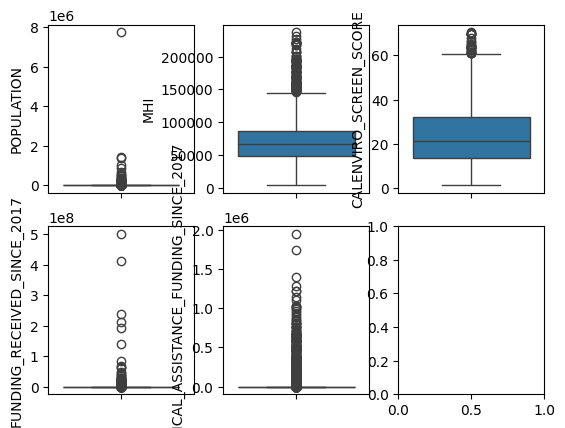

In [6]:
# Plot distributions
fig, axs =  plt.subplots(2,3)
sns.boxplot(water_cont.POPULATION,ax=axs[0,0])
sns.boxplot(water_cont.MHI,ax=axs[0,1])
sns.boxplot(water_cont.CALENVIRO_SCREEN_SCORE,ax=axs[0,2])
sns.boxplot(water_cont.FUNDING_RECEIVED_SINCE_2017,ax=axs[1,0])
sns.boxplot(water_cont.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017,ax=axs[1,1])

The boxplots show that the distributions of all the continuous predictors are extremely right-skewed and on different scales. We will log-transform the data to reduce the right skew and then standardize it to fix the scale differences.

In [7]:
# Log transform
water_cont_log = water_cont.copy()
water_cont_log.POPULATION = np.log(water_cont.POPULATION + 0.1)
water_cont_log.FUNDING_RECEIVED_SINCE_2017 = np.log(
    water_cont.FUNDING_RECEIVED_SINCE_2017 + 0.1)
water_cont_log.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017 = np.log(
    water_cont.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017 + 0.1)

# Standardize
scaler = StandardScaler()
water_cont_scaled = scaler.fit_transform(water_cont_log)

water_cont_scaled = pd.DataFrame(
    scaler.fit_transform(water_cont_log),
    columns=water_cont.columns,
    index=water_cont.index)

<Axes: ylabel='TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017'>

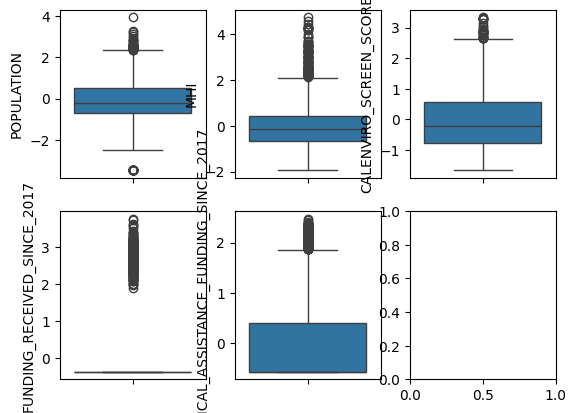

In [8]:
# Plot new distributions
# FIX LABELS
fig, axs =  plt.subplots(2,3)
sns.boxplot(water_cont_scaled.POPULATION,ax=axs[0,0])
sns.boxplot(water_cont_scaled.MHI,ax=axs[0,1])
sns.boxplot(water_cont_scaled.CALENVIRO_SCREEN_SCORE,ax=axs[0,2])
sns.boxplot(water_cont_scaled.FUNDING_RECEIVED_SINCE_2017,ax=axs[1,0])
sns.boxplot(water_cont_scaled.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017,ax=axs[1,1])

In [9]:
# One-hot encode regional board, owner type, federal classification, and current failing
water_one_hot = pd.get_dummies(water_data_clean, 
                               columns=['CURRENT_FAILING', 'REGIONAL_BOARD', 'OWNER_TYPE', 
                                        'FEDERAL_CLASSIFICATION_TYPE'], 
                                        dtype=int)



water_one_hot.columns = ['ID','SERVICE_CONNECTIONS','POPULATION','MHI','CALENVIRO_SCREEN_SCORE',
                         'FUNDING__SINCE_2017','TECH_FUNDING_SINCE_2017','CURRENT_FAILING',
                         'CURRENT_NOT_FAILING','REGIONAL_BOARD_1','REGIONAL_BOARD_2',
                         'REGIONAL_BOARD_3','REGIONAL_BOARD_4','REGIONAL_BOARD_5_FRESNO',
                         'REGIONAL_BOARD_5_REDDING','REGIONAL_BOARD_5_SACRAMENTO',
                         'REGIONAL_BOARD_6_TAHOE','REGIONAL_BOARD_6_VICTORVILLE',
                         'REGIONAL_BOARD_7','REGIONAL_BOARD_8','REGIONAL_BOARD_9',
                         'FEDERAL_GOVERNMENT_OWNED','LOCAL_OWNED','MIXED_OWNED','PRIVATE_OWNED',
                         'STATE_GOVERNMENT_OWNED','FEDERAL_CLASS_COMMUNITY',
                         'FEDERAL_CLASS_NON-TRANSIENT_NON-COMMUNITY',
                         'FEDERAL_CLASS_TRANSIENT_NON-COMMUNITY']

In [10]:
water_one_hot

,ID,SERVICE_CONNECTIONS,POPULATION,MHI,CALENVIRO_SCREEN_SCORE,FUNDING__SINCE_2017,TECH_FUNDING_SINCE_2017,CURRENT_FAILING,CURRENT_NOT_FAILING,REGIONAL_BOARD_1,...,REGIONAL_BOARD_8,REGIONAL_BOARD_9,FEDERAL_GOVERNMENT_OWNED,LOCAL_OWNED,MIXED_OWNED,PRIVATE_OWNED,STATE_GOVERNMENT_OWNED,FEDERAL_CLASS_COMMUNITY,FEDERAL_CLASS_NON-TRANSIENT_NON-COMMUNITY,FEDERAL_CLASS_TRANSIENT_NON-COMMUNITY
0,3,19,50,130464.0,13.969586,0.0,0.00,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,4,191,459,61897.0,31.384971,0.0,0.00,0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,18,207,524,178706.0,10.074452,3000000.0,830.93,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3,19,1,50,140487.0,16.381997,274408.0,0.00,0,1,0,...,0,0,0,1,0,0,0,0,1,0
4,29,86959,344000,157713.0,21.844306,0.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3199,6226,4434,16595,80115.0,28.036047,0.0,169681.22,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3200,6227,1270,4124,74287.0,21.614898,0.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3201,6228,43,122,63664.0,30.214329,0.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3202,6229,795,2772,32000.0,12.323297,443426.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0


In [11]:
# Combine preprocessed categorical and continuous data
water_cat = water_one_hot.drop(['SERVICE_CONNECTIONS','POPULATION',
                                'MHI','CALENVIRO_SCREEN_SCORE',
                                'FUNDING__SINCE_2017',
                                'TECH_FUNDING_SINCE_2017'], axis=1)

# Final cleaned and pre-processed data
water_processed = pd.concat([water_cat, water_cont_scaled], axis=1)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(water_processed.iloc[:,3:],
                                                    water_processed.iloc[:,2],
                                                    train_size=0.9,
                                                    random_state=19)

epochs = [100, 200, 300, 400, 500]
learning_rates = [0.2, 0.25, 0.3, 0.35, 0.4]
loss = []

for i in epochs:
    for j in learning_rates:
        
        model = Sequential([
        Input(shape=(26,)),
        Dense(17, activation='relu'),
        Dense(11, activation='relu'),
        Dense(7, activation='relu'),
        Dense(1, activation='sigmoid'),])

        optimizer = Adam(learning_rate=j)
        model.compile(optimizer=optimizer, loss=BinaryCrossentropy(from_logits=False))
        model.fit(x_train, y_train, epochs=i, validation_data=(x_test, y_test))
        model_eval = model.evaluate(x_test, y_test)
        loss.append(model_eval)
        clear_session()
min_loss = min(loss)
index = loss.index(min_loss)

print(f"The mininum test Binary Crossentropy achieved was {min_loss} using {epochs[index//5]} epochs and ")
print(f"a learning rate of {learning_rates[index%5]}, ")


89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4795 - val_loss: 0.3501
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3667 
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4273 - val_loss: 0.4019
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4122 
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4339 - val_loss: 0.3737
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3836 
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1272 - val_loss: 0.3829
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4314 
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6261 - val_loss: 0.3812
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4149 
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3792 - val_loss: 0.3659
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4073 
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4545 - val_loss: 0.3790
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4250 
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4771 - val_loss: 0.3767
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2